In [1]:
import h5py
import numpy as np
import illustris_python as il
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
def entropy(n,total_num,x):
    counts, bins, bars=plt.hist(x,bins=n)
    #X is the variable for which entropy is calculated
    #n is the number of bins
    #total_num is the total number of data points in x
    p=counts/total_num       #probability
    e=0
    for i in range(len(p)):
        if p[i] != 0:
            e_i=(p[i])*np.log(p[i])
            e=e+e_i
    return -e

############################################################################

def entropy_N_plot(total_num,x,Nmax):
    E=[]  #To append the calculated entropy
    N=np.linspace(1,Nmax,Nmax)   #List of n values to calculate joint entropy
    for i in range(len(N)):
        print(N[i])
        n=int(N[i])
        e=entropy(n,total_num,x)
        print(e)
        E.append(e)
    print(max(E))
    plt.close()
    plt.plot(N,E)
    plt.xlabel('N (integer)')
    plt.ylabel('Entropy')


##########################################################################
    
def joint_entropy(n,total_num,x,y):
    counts, xedges, yedges, im=plt.hist2d(x,y,bins=n)
    jp=counts/total_num
    rows, columns = jp.shape
    je=0
    for i in range(columns):
        je_i=0
        for j in range(rows):
            if jp[j,i] != 0:
                je_i=je_i+(jp[j,i])*np.log(jp[j,i])
        je=je+je_i
    return -je

##########################################################################

def mutual_info(x,y,n,total_num):
    e_x=entropy(n ,total_num,x)  #entropy of x
    e_y=entropy(n ,total_num,y)    #entropy of y

    e_x_y= joint_entropy(n ,total_num,x,y)  #Joint entropy ofx and y

    MI= e_x + e_y - e_x_y #Mutual information= H(x)+H(Y)-H(X,Y)
    me=min(e_x,e_y)   #maximum entropy
    return e_x,e_y,MI/(me)

In [3]:
def mutual(l):
    #calculate all mutual information for l-th snapshot
    res=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/snap_'+str(l)+'_na.csv' , sep=',')
    total_num=len(res)
    n=int(total_num/2)
    print(n)
    print(total_num)
    #x is bar parameters
    #Y is spiral parameters
    b1=res['bar_strength1']      #b1
    b2=res['bar_length1']          #b2
    b3=abs(res['PS'])           #b3
    s1=res['SA']                #s1
    s2=res['pitch_angle']       #s2
    #print(b1)
    
    #Bar_strength and spiral_amplitude
    M_b1_s1=mutual_info(b1,s1,n,total_num)
    #print(M_b1_s1)

    #Bar_strength and spiral_pitch_angle
    M_b1_s2=mutual_info(b1,s2,n,total_num)
    #print(M_b1_s2)

    #Bar_length and spiral_amplitude
    M_b2_s1=mutual_info(b2,s1,n,total_num)
    #print(M_b2_s1)

    #Bar_length and pitch_angle
    M_b2_s2=mutual_info(b2,s2,n,total_num)
    #print(M_b2_s2)

    #Bar_pattern_speed and spiral_amplitude
    M_b3_s1=mutual_info(b3,s1,n,total_num)
    #print(M_b3_s1)

    #Bar_pattern speed and pitch_angle
    M_b3_s2=mutual_info(b3,s2,n,total_num)
    #print(M_b3_s2)
    return M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total_num
    

In [4]:
#snapshot lists from TNG50

SN=np.linspace(65,99,35)
print(SN)
SA=[]
for i in range(len(SN)):
    j=int(SN[i])
    if j != 65 and j != 70 and j != 75 and j != 80 and j != 85 and j != 90 and j != 99 and j != 95:
        SA.append(j)
print(SA)

[65. 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82.
 83. 84. 85. 86. 87. 88. 89. 90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]
[66, 67, 68, 69, 71, 72, 73, 74, 76, 77, 78, 79, 81, 82, 83, 84, 86, 87, 88, 89, 91, 92, 93, 94, 96, 97, 98]


48
97
66 0.6821875408382232 0.6816503703685828 0.5852849674737964 0.5386897297733133 0.5849304793608748 0.5628437102663052 97
48
97
67 0.677022497071998 0.6449599600656121 0.655035940731242 0.6487858456518697 0.6275749097886041 0.5115193925933479 97
48
97
68 0.6940441987934736 0.6918107636400852 0.614478461402856 0.5616913904164903 0.5347565962551125 0.5220424527542435 97
48
96
69 0.6995248322601199 0.6913471575223611 0.6561432249239286 0.6177540541278461 0.6421927539555031 0.5853655897802656 96
48
96
71 0.6934319695052897 0.6803218526551437 0.6442490696312461 0.6465094832172704 0.6276582544458507 0.46502640503374765 96
48
96
72 0.6137595432519991 0.5395039286533098 0.6484844843255534 0.5910970752878365 0.5809642004417225 0.4617717194560788 96
48
97
73 0.606687767538346 0.5835431913386778 0.6535884361514982 0.6139416977135898 0.5515769602526801 0.5241755478417961 97
48
97
74 0.6433221379930231 0.646760587722417 0.6111239742115043 0.5642090573071673 0.6136891412105525 0.5411994185954977

ValueError: autodetected range of [nan, nan] is not finite

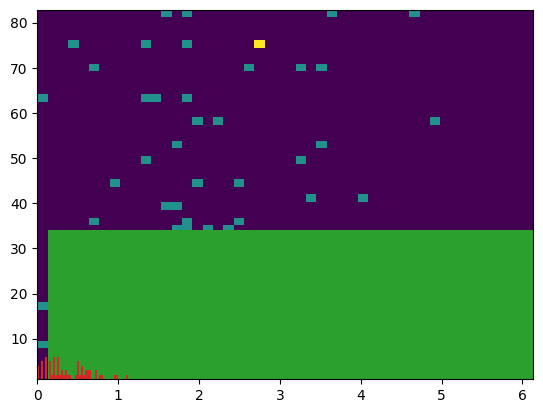

In [12]:
fb=open('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_na.csv','w')#id of galaxies at snapshot 99
print('snapshot','M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2','total',file=fb)
for j in SA:
    M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total=mutual(j)
    print(j,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total)
    print(j,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total, file=fb)
    #Y11.append(M_b1_s1[2])
    #Y12.append(M_b1_s2[2])
    #Y21.append(M_b2_s1[2])
    #Y22.append(M_b2_s2[2])
    #Y31.append(M_b3_s1[2])
    #Y32.append(M_b3_s2[2])
    #T.append(total)
fb.close()
    

In [14]:
# DataFrames
file1='/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information.csv'
df1 = pd.read_csv(file1,sep=',')

file2='/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_na.csv'
df2 = pd.read_csv(file2,sep=',')

# Merge and save to a new DataFrame
new_df = pd.concat([df1, df2], ignore_index=True)

# Print or use new_df
print(new_df)

new_df.to_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_total.csv', index=False)

    snapshot   M_b1_s1   M_b1_s2   M_b2_s1   M_b2_s2   M_b3_s1   M_b3_s2  \
0         65  0.640371  0.650457  0.592095  0.639938  0.553310  0.548875   
1         70  0.648772  0.634198  0.628802  0.556709  0.580828  0.547131   
2         75  0.681606  0.684282  0.625454  0.613803  0.630144  0.570035   
3         80  0.549738  0.545675  0.568479  0.602193  0.450802  0.460020   
4         85  0.650395  0.663381  0.574204  0.577465  0.571247  0.560674   
5         90  0.638294  0.633248  0.613438  0.568498  0.538339  0.474412   
6         95  0.695159  0.687633  0.653265  0.538251  0.599006  0.461979   
7         99  0.506602  0.513192  0.596354  0.578915  0.490975  0.433895   
8         66  0.682188  0.681650  0.585285  0.538690  0.584930  0.562844   
9         67  0.677022  0.644960  0.655036  0.648786  0.627575  0.511519   
10        68  0.694044  0.691811  0.614478  0.561691  0.534757  0.522042   
11        69  0.699525  0.691347  0.656143  0.617754  0.642193  0.585366   
12        71

In [32]:
print(T)

[97, 97, 97, 97, 97, 97, 97, 97]


In [33]:
print(Y11)
print('---')
print(Y12)
print('---')
print(Y21)
print('---')
print(Y22)
print('---')
print(Y31)
print('---')
print(Y32)
print('---')

[0.6403712641969264, 0.6487720057581321, 0.6816061539903109, 0.5497380337360105, 0.6503951326808531, 0.6382935821741857, 0.695159293091396, 0.5066024427376793]
---
[0.6504569072519027, 0.634198265218547, 0.6842818238001154, 0.5456749775297365, 0.6633806983797134, 0.6332480796882095, 0.687633349874231, 0.5131915778631116]
---
[0.592094885215964, 0.6288020344531434, 0.6254544694667196, 0.5684790130858526, 0.5742042539315989, 0.6134378877126179, 0.6532646294490164, 0.596353549774706]
---
[0.6399377504527054, 0.556708909374073, 0.6138031573949565, 0.6021932520340316, 0.5774652315271103, 0.5684981441674429, 0.5382506012244321, 0.5789147264736375]
---
[0.5533097967232888, 0.5808278092459623, 0.6301435198740852, 0.4508024294625964, 0.5712467512121313, 0.5383387641900887, 0.5990058960193146, 0.49097471098506484]
---
[0.5488750013946151, 0.5471309945364443, 0.5700354456428384, 0.46002035748057113, 0.5606738511823327, 0.47441217702164984, 0.46197863968147357, 0.43389471143278263]
---


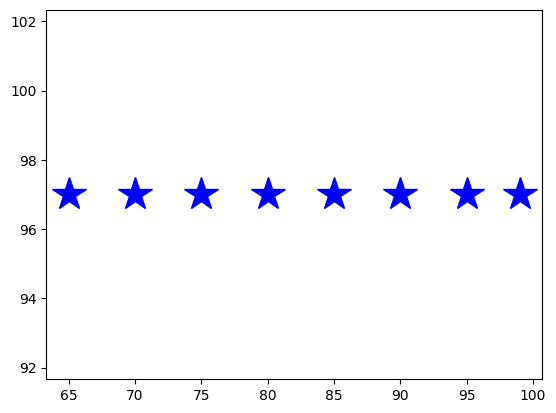

In [20]:
plt.plot(X,T,'*', color ='b', markersize=25)

In [45]:
def fit(X,Y):
    X=np.array(X)
    Y=np.array(Y)
    coeffs = np.polyfit(X, Y, 1)  # 1 for linear
    m, c = coeffs
    #print(f"Slope (m): {m}, Intercept (c): {c}")
    return m,c

Slope (m): -0.0016877568887135196, Intercept (c): 0.7653962122534627


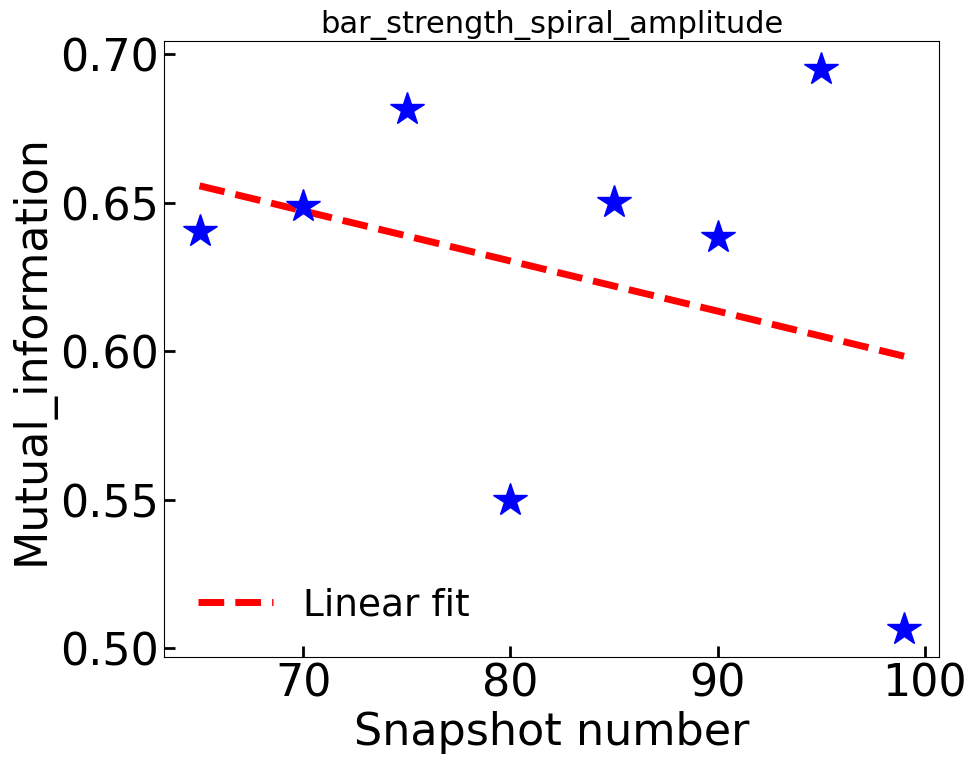

In [47]:
#plt.subplots(figsize=(10, 8))




fig, ax=plt.subplots(ncols =1, nrows =1, figsize = [10,8])
m,c=fit(X,Y11)
print(f"Slope (m): {m}, Intercept (c): {c}")
plt.plot(X, m*X + c, '--', color ='r', linewidth=5, label='Linear fit')
plt.plot(X,Y11,'*', color ='b', markersize=25)





plt.xlabel('Snapshot number',fontsize=32)
plt.ylabel('Mutual_information',fontsize=32)
plt.tick_params(axis = 'x', labelsize = 32, width = 2, length = 8,direction="in")
ax.tick_params(axis = 'y', labelsize = 32, width = 2, length = 8,direction="in")
plt.title('bar_strength_spiral_amplitude',fontsize=22)
plt.legend(fontsize=27, frameon=False)
plt.savefig('bar_strength_spiral_amplitude.pdf',bbox_inches='tight',pad_inches=0.1)

Slope (m): 0.0003097384981385554, Intercept (c): 0.5809966316020385


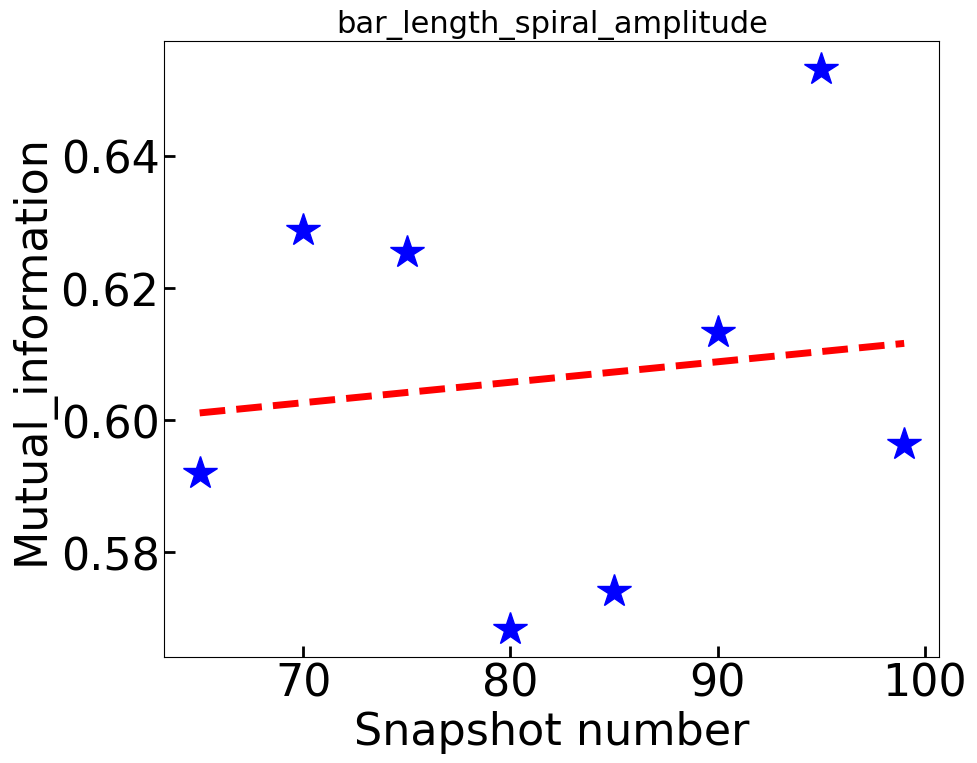

In [48]:
fig, ax=plt.subplots(ncols =1, nrows =1, figsize = [10,8])

m,c=fit(X,Y21)
print(f"Slope (m): {m}, Intercept (c): {c}")
plt.plot(X, m*X + c, '--', color ='r', linewidth=5, label='Linear fit')

plt.plot(X,Y21,'*', color ='b', markersize=25)
plt.xlabel('Snapshot number',fontsize=32)
plt.ylabel('Mutual_information',fontsize=32)
plt.tick_params(axis = 'x', labelsize = 32, width = 2, length = 8,direction="in")
ax.tick_params(axis = 'y', labelsize = 32, width = 2, length = 8,direction="in")
plt.title('bar_length_spiral_amplitude',fontsize=22)
#plt.legend(fontsize=27, frameon=False)
plt.savefig('bar_length_spiral_amplitude.pdf',bbox_inches='tight',pad_inches=0.1)

Slope (m): -0.0011716070188548247, Intercept (c): 0.6483423378922324


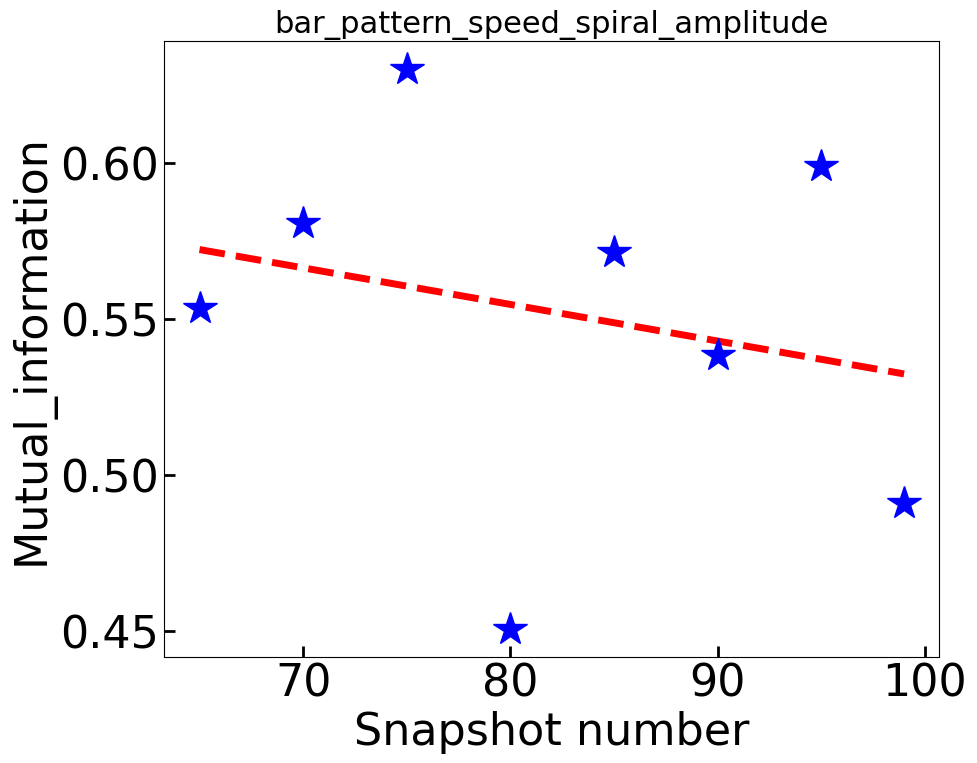

In [49]:
fig, ax=plt.subplots(ncols =1, nrows =1, figsize = [10,8])

m,c=fit(X,Y31)
print(f"Slope (m): {m}, Intercept (c): {c}")
plt.plot(X, m*X + c, '--', color ='r', linewidth=5, label='Linear fit')

plt.plot(X,Y31,'*', color ='b', markersize=25)
plt.xlabel('Snapshot number',fontsize=32)
plt.ylabel('Mutual_information',fontsize=32)
plt.tick_params(axis = 'x', labelsize = 32, width = 2, length = 8,direction="in")
ax.tick_params(axis = 'y', labelsize = 32, width = 2, length = 8,direction="in")
plt.title('bar_pattern_speed_spiral_amplitude',fontsize=22)
#plt.legend(fontsize=27, frameon=False)
plt.savefig('bar_pattern_speed_spiral_amplitude.pdf',bbox_inches='tight',pad_inches=0.1)

Slope (m): -0.0016826645529563753, Intercept (c): 0.7651177025004771


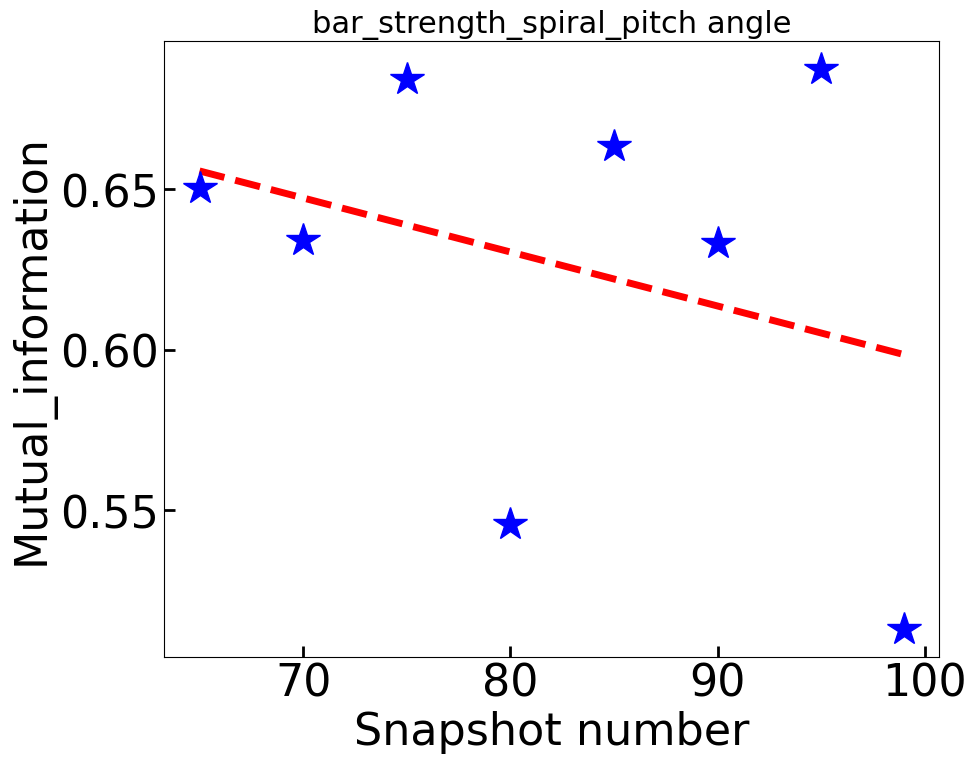

In [52]:
fig, ax=plt.subplots(ncols =1, nrows =1, figsize = [10,8])


m,c=fit(X,Y12)
print(f"Slope (m): {m}, Intercept (c): {c}")
plt.plot(X, m*X + c, '--', color ='r', linewidth=5, label='Linear fit')

plt.plot(X,Y12,'*', color ='b', markersize=25)
plt.xlabel('Snapshot number',fontsize=32)
plt.ylabel('Mutual_information',fontsize=32)
plt.tick_params(axis = 'x', labelsize = 32, width = 2, length = 8,direction="in")
ax.tick_params(axis = 'y', labelsize = 32, width = 2, length = 8,direction="in")
plt.title('bar_strength_spiral_pitch angle',fontsize=22)
#plt.legend(fontsize=27, frameon=False)
plt.savefig('bar_strength_spiral_pitch.pdf',bbox_inches='tight',pad_inches=0.1)

Slope (m): -0.001668200001841209, Intercept (c): 0.721889446732718


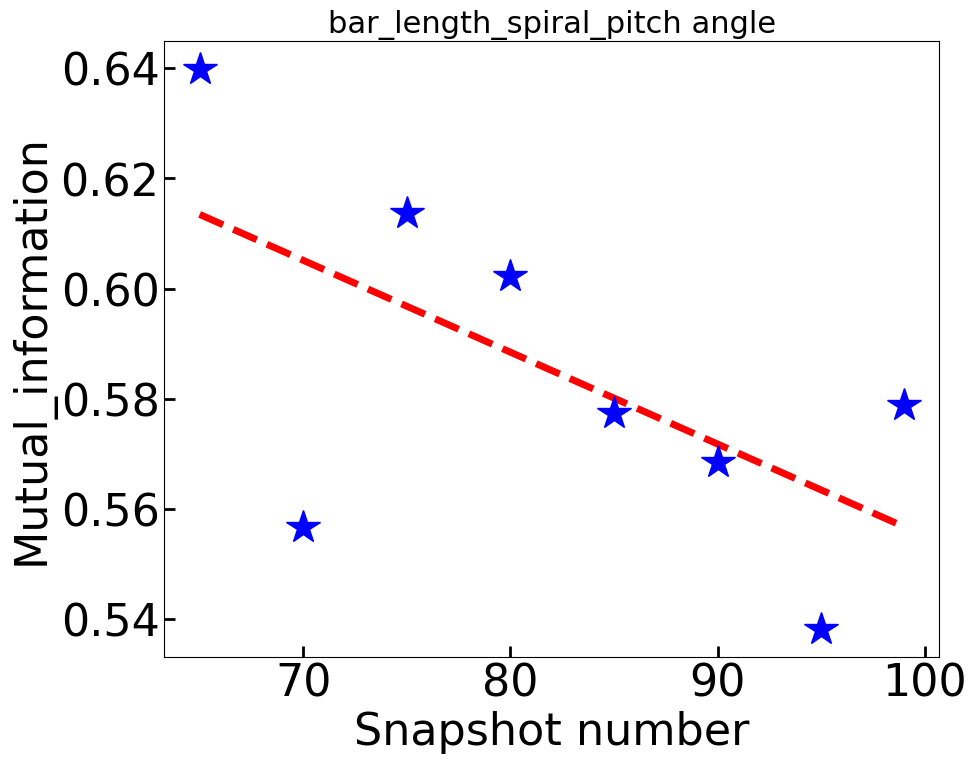

In [53]:
fig, ax=plt.subplots(ncols =1, nrows =1, figsize = [10,8])

m,c=fit(X,Y22)
print(f"Slope (m): {m}, Intercept (c): {c}")
plt.plot(X, m*X + c, '--', color ='r', linewidth=5, label='Linear fit')


plt.plot(X,Y22,'*', color ='b', markersize=25)
plt.xlabel('Snapshot number',fontsize=32)
plt.ylabel('Mutual_information',fontsize=32)
plt.tick_params(axis = 'x', labelsize = 32, width = 2, length = 8,direction="in")
ax.tick_params(axis = 'y', labelsize = 32, width = 2, length = 8,direction="in")
plt.title('bar_length_spiral_pitch angle',fontsize=22)
#plt.legend(fontsize=27, frameon=False)
plt.savefig('bar_length_spiral_pitch.pdf',bbox_inches='tight',pad_inches=0.1)

Slope (m): -0.0034146596328878116, Intercept (c): 0.7884102345557218


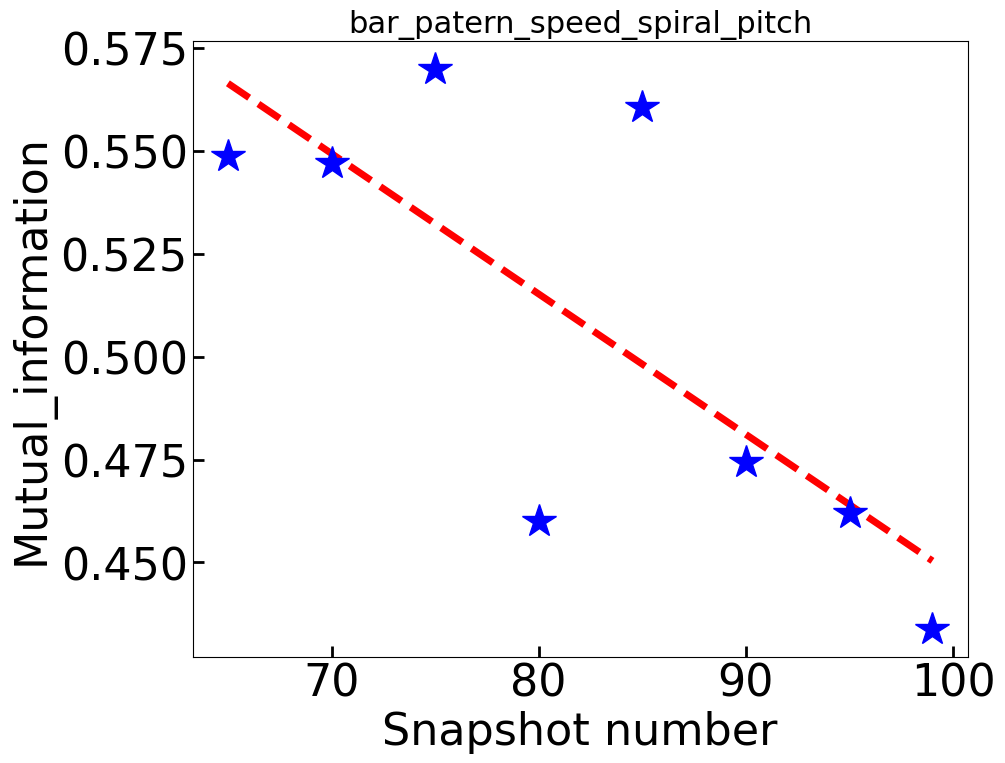

In [54]:
fig, ax=plt.subplots(ncols =1, nrows =1, figsize = [10,8])

m,c=fit(X,Y32)
print(f"Slope (m): {m}, Intercept (c): {c}")
plt.plot(X, m*X + c, '--', color ='r', linewidth=5, label='Linear fit')

plt.plot(X,Y32,'*', color ='b', markersize=25)
plt.xlabel('Snapshot number',fontsize=32)
plt.ylabel('Mutual_information',fontsize=32)
plt.tick_params(axis = 'x', labelsize = 32, width = 2, length = 8,direction="in")
ax.tick_params(axis = 'y', labelsize = 32, width = 2, length = 8,direction="in")
plt.title('bar_patern_speed_spiral_pitch',fontsize=22)
#plt.legend(fontsize=27, frameon=False)
plt.savefig('bar_patern_speed_spiral_pitch.pdf',bbox_inches='tight',pad_inches=0.1)

## Two groups

In [5]:
import numpy as np
from scipy import stats
from scipy import ndimage
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd
import scipy
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [6]:
f1=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Roseguvera_samples/new_17_oct/samples/formation_1_IDs.csv',sep=',')
ID1=f1['id']
f0=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Roseguvera_samples/new_17_oct/samples/formation_0_IDs.csv',sep=',')
ID0=f0['id']

In [7]:
SN=np.linspace(65,99,35)
print(SN)
SA=[]
SS=[]
for i in range(len(SN)):
    j=int(SN[i])
    if j != 65 and j != 70 and j != 75 and j != 80 and j != 85 and j != 90 and j != 99 and j != 95:
        SA.append(j)
    else:
        SS.append(j)
print(SA)
print(SS)
'''
fb=open('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_na.csv','w')#id of galaxies at snapshot 99
print('snapshot','M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2','total',file=fb)
for j in SA:
    M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total=mutual(j)
    print(j,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total)
    print(j,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total, file=fb)
    #Y11.append(M_b1_s1[2])
    #Y12.append(M_b1_s2[2])
    #Y21.append(M_b2_s1[2])
    #Y22.append(M_b2_s2[2])
    #Y31.append(M_b3_s1[2])
    #Y32.append(M_b3_s2[2])
    #T.append(total)
fb.close()
'''

[65. 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82.
 83. 84. 85. 86. 87. 88. 89. 90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]
[66, 67, 68, 69, 71, 72, 73, 74, 76, 77, 78, 79, 81, 82, 83, 84, 86, 87, 88, 89, 91, 92, 93, 94, 96, 97, 98]
[65, 70, 75, 80, 85, 90, 95, 99]


"\nfb=open('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_na.csv','w')#id of galaxies at snapshot 99\nprint('snapshot','M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2','total',file=fb)\nfor j in SA:\n    M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total=mutual(j)\n    print(j,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total)\n    print(j,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total, file=fb)\n    #Y11.append(M_b1_s1[2])\n    #Y12.append(M_b1_s2[2])\n    #Y21.append(M_b2_s1[2])\n    #Y22.append(M_b2_s2[2])\n    #Y31.append(M_b3_s1[2])\n    #Y32.append(M_b3_s2[2])\n    #T.append(total)\nfb.close()\n"

In [8]:
#new_df.to_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_total.csv', index=False)
#/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/final_result/snap_99_final.csv
s99=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/final_result/snap_'+str(99)+'_final.csv' , sep=',')
print(s99)

    Num      id   R50_s  bar_strength  bar_length  R_at_A2max  RB0    SA  \
0     0   63875  1.0944      0.050000    0.600000         0.4    0  0.45   
1     2  275550  1.3017      0.200000    1.000000         0.5    0  0.50   
2     4  313692  5.8919      0.150000    3.000000         1.0    0  0.22   
3     5  313693  2.8313      0.340000    1.200000         0.7    0  0.40   
4     6  264885  2.3933      0.380000    1.200000         0.9    0  0.60   
..  ...     ...     ...           ...         ...         ...  ...   ...   
92   12  565089  4.7252      0.617529    4.534580         1.0    0  0.28   
93   13  566365  3.0725      0.372811    2.517195         1.0    0  1.00   
94   14  570598  2.3324      0.473935    2.575879         1.0    0  0.12   
95   15  585282  2.6723      0.470104    2.883315         1.0    0  1.00   
96   16  595887  2.1748      0.289391    2.176631         1.0    0  0.62   

            PS  pitch_angle  
0    86.815731        82.87  
1   696.313361        82.87

In [9]:
#print(ID1)
#print(ID0)
IDN0=[]
for i in range (len(ID0)):
    IDN0.append(int(ID0[i]))
    
IDN1=[]
for i in range (len(ID1)):
    IDN1.append(int(ID1[i]))

print(IDN0)
    

[313693, 307487, 371126, 398784, 427211, 481428, 264886, 492876, 519311, 522530, 487742, 455291, 546114, 523889, 532760, 441709, 497557, 543376, 535050, 555601, 568923, 264889, 560082, 521429, 527310, 564268, 456327, 583745, 614489, 631677, 588986, 676758, 300905, 595887, 229935, 371127, 456326, 460723, 487743, 488530, 500577, 505101, 509091, 535410, 536146, 548418, 566365, 569251, 570598, 585282]


In [10]:
print(len(IDN0),len(IDN1))

50 51


In [11]:
Num0=[]
Num1=[]
for i in range(len(s99)):
    id = int(s99['id'][i])
    #print(id)
    if id in IDN0:
        Num0.append(s99["Num"][i])
    elif id in IDN1:
        Num1.append(s99["Num"][i])
    else:
        print(id)
        print('no')

    

449659
no


In [12]:
print(Num0,Num1)

[5, 7, 8, 14, 17, 24, 26, 27, 32, 37, 40, 43, 44, 46, 48, 50, 51, 53, 54, 55, 59, 61, 62, 63, 64, 66, 69, 71, 72, 74, 79, 80, 81, 86, 87, 88, 91, 2, 6, 7, 8, 9, 10, 13, 14, 15, 16] [0, 2, 4, 6, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 28, 29, 31, 33, 34, 36, 38, 39, 41, 42, 45, 47, 49, 52, 57, 58, 60, 67, 68, 70, 75, 76, 78, 83, 84, 85, 90, 0, 1, 3, 4, 11, 12]


In [13]:
print(len(Num0),len(Num1))

47 49


In [20]:
def mutual_two_groups(l,formation_num):
    #calculate all mutual information for l-th snapshot
    res=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/final_result/snap_'+str(l)+'_final.csv' , sep=',')
    b1= []     #b1
    b2= []        #b2
    b3= []         #b3
    s1= []              #s1
    s2=[]
    for j in range(len(res)):
        if res['Num'][j] in formation_num:

            ps_val = abs(res['PS'][j])

            if pd.notna(ps_val):       # only append if NOT NaN
                b1.append(res['bar_strength'][j])
                b2.append(res['bar_length'][j])
                b3.append(ps_val)      # cleaned b3
                s1.append(res['SA'][j])
                s2.append(res['pitch_angle'][j])
            
    total_num=len(b1)
    n=int(total_num/3)
    print(n)
    print(total_num)
    print(b3,s1)
    #x is bar parameters
    #Y is spiral parameters
          #s2
    #print(b1,b2,b3,s1,s2)
    
    #Bar_strength and spiral_amplitude
    M_b1_s1=mutual_info(b1,s1,n,total_num)
    #print(M_b1_s1)

    #Bar_strength and spiral_pitch_angle
    M_b1_s2=mutual_info(b1,s2,n,total_num)
    #print(M_b1_s2)

    #Bar_length and spiral_amplitude
    M_b2_s1=mutual_info(b2,s1,n,total_num)
    #print(M_b2_s1)

    #Bar_length and pitch_angle
    M_b2_s2=mutual_info(b2,s2,n,total_num)
    #print(M_b2_s2)

    #Bar_pattern_speed and spiral_amplitude
    M_b3_s1=mutual_info(b3,s1,n,total_num)
    #print(M_b3_s1)

    #Bar_pattern speed and pitch_angle
    M_b3_s2=mutual_info(b3,s2,n,total_num)
    #print(M_b3_s2)
    return M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total_num

In [18]:
 mutual_two_groups(93,Num0)

14
43
[1.0, 19.9006515456763, 77.6691274057796, 36.6199874225809, 8.3448851798542, 16.2433702681294, 13.2528686426342, 53.8263150597653, 38.1957026124612, 17.8138586221529, 0.239434562529391, 31.7011246039708, 35.2312263015104, 7.63999281777524, 49.8176818886776, 8.94820048342378, 7.26298381665072, 166.338807027227, 25.6068275844738, 18.0550635171561, 11.7088989294515, 43.2129975834325, 27.7677891313087, 24.9677879569533, 13.7023257186691, 19.0232447145922, 0.132373763694812, 69.3372961004159, 84.6359668577444, 6.85475312819222, 44.0956987023419, 149.350009686153, 54.6056982389871, 167.559510565707, 2.07981881496021, 10.1638135037823, 5.88367831349144, 39.4153886834495, 23.5603460398673, 157.319492231565, 23.5603460398673, 86.8281439524862, 35.1368139454178] [0.0, 0.55, 0.27, 0.34, 0.45, 0.29, 0.1, 0.1, 0.55, 0.34, 0.62, 0.44, 0.42, 0.21, 0.85, 1.0, 0.74, 0.23, 0.0, 0.15, 0.0, 0.38, 0.61, 0.3, 0.38, 0.63, 1.1, 0.37, 0.15, 1.1, 0.49, 0.75, 0.2, 0.11, 1.19, 0.95, 0.8, 0.27, 0.54, 0.17, 0

NameError: name 'mutual_info' is not defined

65
18
55
[80.6410373253128, 52.5006705735192, 41.0571924520515, 26.074696407905, 33.7556138802206, 67.2696574283296, 41.7733364798557, 72.5028899915318, 134.977433549454, 4.62562089185518, 7.28052752170366, 88.2312765626693, 29.6129565455655, 47.7179340961635, 5.00005911933334, 26.0326252219732, 127.333980156753, 131.262390001971, 25.2702238383617, 107.571991125225, 46.7823261103879, 43.1987390668812, 40.6727030966053, 177.24234600695, 17.5127742366512, 81.5082455640701, 44.9546347751629, 57.3198063752912, 75.3432600359909, 10.3802085086117, 90.4605088444965, 114.448548098794, 30.9350085100246, 33.6533656686879, 95.9710258454668, 56.1496722335378, 28.2052215105285, 19.9688214226314, 8.48411140630481, 22.2642078439378, 67.5276119626102, 42.9713587879075, 43.8007679387201, 27.6991240078572, 53.4482497079953, 23.3944164983882, 67.7301427904783, 98.500651389264, 13.4919573678066, 34.3776337047335, 9.23277466529383, 55.2944532192662, 0.0, 15.2897055181792, 9.42285720505133] [0.4380313056911

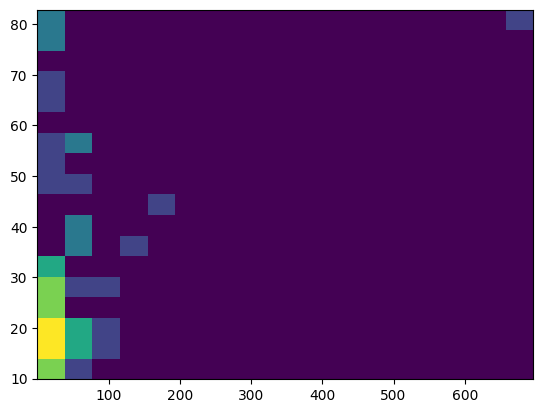

In [29]:
fb0=open('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_0.csv','w')#id of galaxies at snapshot 99
print('snapshot','M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2','total',file=fb0)
for j in range(len(SN)):
    l=int(SN[j])
    print(l)
    try:
        M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total=mutual_two_groups(l,Num0)
        print(l,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total)
        print(l,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total, file=fb0)
    except Exception as e:
        print(l,e)
        continue
    #Y11.append(M_b1_s1[2])
    #Y12.append(M_b1_s2[2])
    #Y21.append(M_b2_s1[2])
    #Y22.append(M_b2_s2[2])
    #Y31.append(M_b3_s1[2])
    #Y32.append(M_b3_s2[2])
    #T.append(total)
fb0.close()

65
18
56
[36.8761525852471, 80.6410373253128, 24.7052442330992, 41.0571924520515, 67.2696574283296, 41.7733364798557, 110.360653464851, 72.5028899915318, 4.62562089185518, 7.28052752170366, 31.5542057495195, 82.1734824080457, 44.2508378312717, 152.634657088486, 71.4780451420555, 65.5229997395941, 35.2077037885636, 171.152323547652, 108.357722722392, 41.2252347356138, 31.1258350004872, 18.0605214002861, 37.2226279496724, 59.3076787754478, 87.4696530753736, 144.707149620297, 35.9798769600331, 33.1891815136956, 240.459137021402, 11.9685001543076, 79.589889755001, 17.9012300419876, 13.2427291353735, 22.3249937029716, 92.7377544987967, 18.7898848543832, 30.622826834862, 1.98287920383522, 80.6951888403766, 59.6556490467704, 28.6282693300025, 66.6266580919076, 14.0437902879186, 3.01113107325472, 43.500446681414, 53.4482497079953, 13.6666088051393, 27.8105012856506, 67.7301427904783, 34.3776337047335, 11.5798681467165, 9.23277466529383, 55.2944532192662, 0.0, 15.2897055181792, 4.46115158419553

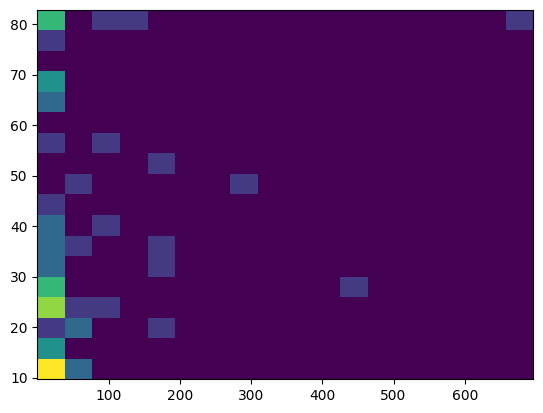

In [22]:

fb1=open('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_1.csv','w')#id of galaxies at snapshot 99
print('snapshot','M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2','total',file=fb1)
for j in range(len(SN)):
    l=int(SN[j])
    print(l)
    M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total=mutual_two_groups(l,Num1)
    print(l,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total)
    print(l,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total, file=fb1)
    #Y11.append(M_b1_s1[2])
    #Y12.append(M_b1_s2[2])
    #Y21.append(M_b2_s1[2])
    #Y22.append(M_b2_s2[2])
    #Y31.append(M_b3_s1[2])
    #Y32.append(M_b3_s2[2])
    #T.append(total)
fb1.close()

## ploting

In [30]:
#'/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_total.csv'

fbt=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_total.csv' , sep=',')
fb1=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_1.csv', sep=' ')
fb0=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_0.csv', sep=' ')
print(fbt)
print(fb1)
print(fb0)

    snapshot   M_b1_s1   M_b1_s2   M_b2_s1   M_b2_s2   M_b3_s1   M_b3_s2  \
0         65  0.640371  0.650457  0.592095  0.639938  0.553310  0.548875   
1         70  0.648772  0.634198  0.628802  0.556709  0.580828  0.547131   
2         75  0.681606  0.684282  0.625454  0.613803  0.630144  0.570035   
3         80  0.549738  0.545675  0.568479  0.602193  0.450802  0.460020   
4         85  0.650395  0.663381  0.574204  0.577465  0.571247  0.560674   
5         90  0.638294  0.633248  0.613438  0.568498  0.538339  0.474412   
6         95  0.695159  0.687633  0.653265  0.538251  0.599006  0.461979   
7         99  0.506602  0.513192  0.596354  0.578915  0.490975  0.433895   
8         66  0.682188  0.681650  0.585285  0.538690  0.584930  0.562844   
9         67  0.677022  0.644960  0.655036  0.648786  0.627575  0.511519   
10        68  0.694044  0.691811  0.614478  0.561691  0.534757  0.522042   
11        69  0.699525  0.691347  0.656143  0.617754  0.642193  0.585366   
12        71

In [27]:
fbs=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/TNG_details.csv',sep=',')
print(fbs)

    Snapshot     Age  Redshift  Unnamed: 3  Lookback          Gas       Cells  \
0         99  13.803      0.00         NaN     0.000   8737803526  1289575331   
1         98  13.667      0.01         NaN     0.136   8741176521  1284694806   
2         97  13.463      0.02         NaN     0.340   8746243655  1277242258   
3         96  13.328      0.03         NaN     0.475   8749771474  1272215071   
4         95  13.127      0.05         NaN     0.676   8755108332  1264516351   
..       ...     ...       ...         ...       ...          ...         ...   
95         4   0.475     10.00         NaN    13.328   9996304486     2129923   
96         3   0.418     10.98         NaN    13.385  10025561598     1483071   
97         2   0.370     11.98         NaN    13.433  10045762350     1048512   
98         1   0.271     14.99         NaN    13.532  10071893231      350802   
99         0   0.179     20.05         NaN    13.624  10077543839       32972   

    Stars       Bhs      Fo

In [32]:
#
'''
print(fb0)
fb0['Age']=1
fb0['redshift']=1
for i in range(len(fb0)):
    for j in range(len(fbs)):
        if fb0['snapshot'][i]==fbs['Snapshot'][j]:
            fb0['Age'][i]=fbs['Age'][j]
            fb0['redshift'][i]=fbs['Redshift'][j]
fb0.to_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_0.csv', index=False)
'''
fb0=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_0.csv', sep=',')
print(fb0)
    

    snapshot   M_b1_s1   M_b1_s2   M_b2_s1   M_b2_s2   M_b3_s1   M_b3_s2  \
0         65  0.480778  0.567515  0.434547  0.476974  0.420056  0.473201   
1         66  0.482606  0.515913  0.378278  0.376157  0.413095  0.433327   
2         67  0.519682  0.490147  0.460050  0.521270  0.483569  0.369765   
3         68  0.460628  0.501012  0.373288  0.377441  0.411848  0.498686   
4         69  0.498032  0.532375  0.422057  0.429232  0.467994  0.507754   
5         70  0.462990  0.487963  0.527432  0.476309  0.428544  0.451895   
6         71  0.449259  0.473071  0.448529  0.456286  0.399737  0.393694   
7         72  0.450560  0.551483  0.395515  0.414537  0.351532  0.319218   
8         73  0.459337  0.527070  0.429499  0.515222  0.397471  0.428818   
9         74  0.388206  0.501117  0.510204  0.449013  0.441373  0.377179   
10        75  0.509499  0.487463  0.468542  0.464891  0.505148  0.390245   
11        76  0.420610  0.504444  0.382170  0.416971  0.442966  0.436500   
12        77

In [33]:
print(fb1)
fb1['Age']=1
fb1['redshift']=1
for i in range(len(fb1)):
    for j in range(len(fbs)):
        if fb1['snapshot'][i]==fbs['Snapshot'][j]:
            fb1['Age'][i]=fbs['Age'][j]
            fb1['redshift'][i]=fbs['Redshift'][j]
fb1.to_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_1.csv', index=False)
fb1=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/mutual_information_formation_1.csv', sep=',')
print(fb1)

    snapshot   M_b1_s1   M_b1_s2   M_b2_s1   M_b2_s2   M_b3_s1   M_b3_s2  \
0         65  0.474932  0.542593  0.550217  0.561679  0.393230  0.450176   
1         66  0.512007  0.510326  0.502860  0.421340  0.514522  0.423770   
2         67  0.526652  0.501359  0.474437  0.539105  0.360457  0.433931   
3         68  0.498613  0.480273  0.469232  0.416514  0.462108  0.437978   
4         69  0.553880  0.538222  0.549323  0.471512  0.487160  0.433630   
5         70  0.531465  0.521914  0.475827  0.467338  0.448201  0.438739   
6         71  0.502193  0.516760  0.459312  0.535053  0.461053  0.351791   
7         72  0.559657  0.542402  0.515223  0.549113  0.405689  0.475093   
8         73  0.563904  0.569209  0.500280  0.497448  0.390938  0.418762   
9         74  0.542030  0.558198  0.459139  0.473675  0.502748  0.393478   
10        75  0.589599  0.516429  0.562080  0.549592  0.500490  0.430074   
11        76  0.568527  0.489959  0.525459  0.537907  0.477532  0.457974   
12        77

/tmp/ipykernel_335897/624305950.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fb1['Age'][i]=fbs['Age'][j]
/tmp/ipykernel_335897/624305950.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '8.28' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fb1['Age'][i]=fbs['Age'][j]
/tmp/ipykernel_335897/624305950.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fb1['redshift'][i]=fbs['Redshift'][j]
/tmp/ipykernel_335897/624305950.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will

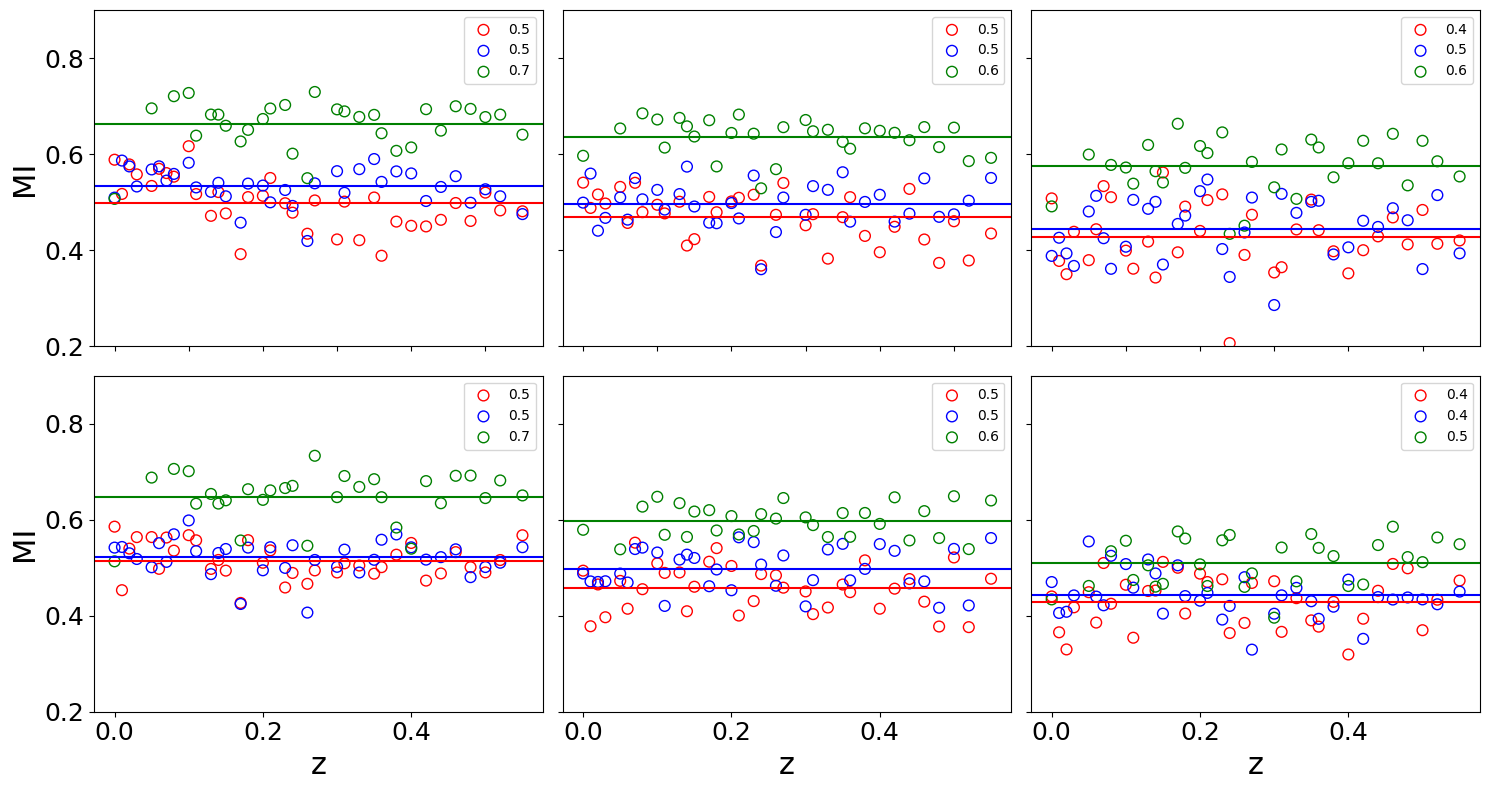

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

# Row 1
plt.subplot(2, 3, 1)
plt.scatter(fb0['redshift'], fb0['M_b1_s1'], marker='o',s=60,  facecolors='none', edgecolors='red',
            label=f"{fb0['M_b1_s1'].median():.1f}")
plt.scatter(fb1['redshift'], fb1['M_b1_s1'], marker='o', s=60, facecolors='none', edgecolors='blue',
            label=f"{fb1['M_b1_s1'].median():.1f}")
plt.scatter(fbt['redshift'], fbt['M_b1_s1'], marker='o',s=60,  facecolors='none', edgecolors='green',
            label=f"{fbt['M_b1_s1'].median():.1f}")

plt.axhline(fb0['M_b1_s1'].mean(), c='r', linestyle='-', linewidth='1.5')
plt.axhline(fb1['M_b1_s1'].mean(), c='b', linestyle='-', linewidth='1.5')
plt.axhline(fbt['M_b1_s1'].mean(), c='g', linestyle='-', linewidth='1.5')

#plt.text(70, 0.8, r"$A_{2\mathrm{bar}}$ - $A_{2\mathrm{spiral}}$", fontsize=12,bbox=dict(facecolor='white', edgecolor='black', pad=3))
plt.ylabel("MI", fontsize=22)
plt.ylim(0.2, 0.9)
plt.tick_params(axis="x", labelbottom=False)
plt.tick_params(axis="y", labelsize=18)
plt.legend()

plt.subplot(2, 3, 2)
plt.scatter(fb0['redshift'], fb0['M_b2_s1'], marker='o', s=60 ,facecolors='none', edgecolors='red',
            label=f"{fb0['M_b2_s1'].median():.1f}")
plt.scatter(fb1['redshift'], fb1['M_b2_s1'], marker='o',s=60 , facecolors='none', edgecolors='blue',
            label=f"{fb1['M_b2_s1'].median():.1f}")
plt.scatter(fbt['redshift'], fbt['M_b2_s1'], marker='o',s=60 , facecolors='none', edgecolors='green',
            label=f"{fbt['M_b2_s1'].median():.1f}")

plt.axhline(fb0['M_b2_s1'].mean(), c='r', linestyle='-', linewidth='1.5')
plt.axhline(fb1['M_b2_s1'].mean(), c='b', linestyle='-', linewidth='1.5')
plt.axhline(fbt['M_b2_s1'].mean(), c='g', linestyle='-', linewidth='1.5')

#plt.text(70, 0.8, r"$r_{\mathrm{bar}}$ - $A_{2\mathrm{spiral}}$", fontsize=12,bbox=dict(facecolor='white', edgecolor='black', pad=3))
plt.ylim(0.2, 0.9)
plt.tick_params(axis="x", labelbottom=False)
plt.tick_params(axis="y", labelsize=18, labelleft=False)
plt.legend()

plt.subplot(2, 3, 3)
plt.scatter(fb0['redshift'], fb0['M_b3_s1'], marker='o', s=60, facecolors='none', edgecolors='red',
            label=f"{fb0['M_b3_s1'].median():.1f}")
plt.scatter(fb1['redshift'], fb1['M_b3_s1'], marker='o', s=60, facecolors='none', edgecolors='blue',
            label=f"{fb1['M_b3_s1'].median():.1f}")
plt.scatter(fbt['redshift'], fbt['M_b3_s1'], marker='o', s=60, facecolors='none', edgecolors='green',
            label=f"{fbt['M_b3_s1'].median():.1f}")

plt.axhline(fb0['M_b3_s1'].mean(), c='r', linestyle='-', linewidth='1.5')
plt.axhline(fb1['M_b3_s1'].mean(), c='b', linestyle='-', linewidth='1.5')
plt.axhline(fbt['M_b3_s1'].mean(), c='g', linestyle='-', linewidth='1.5')

#plt.text(70, 0.8, r"$\Omega$ - $A_{2\mathrm{spiral}}$", fontsize=12,bbox=dict(facecolor='white', edgecolor='black', pad=3))
plt.ylim(0.2, 0.9)
plt.tick_params(axis="x", labelbottom=False)
plt.tick_params(axis="y", labelsize=18, labelleft=False)
plt.legend()

# Row 2
plt.subplot(2, 3, 4)
plt.scatter(fb0['redshift'], fb0['M_b1_s2'], marker='o', s=60,facecolors='none', edgecolors='red',
            label=f"{fb0['M_b1_s2'].median():.1f}")
plt.scatter(fb1['redshift'], fb1['M_b1_s2'], marker='o', s=60,facecolors='none', edgecolors='blue',
            label=f"{fb1['M_b1_s2'].median():.1f}")
plt.scatter(fbt['redshift'], fbt['M_b1_s2'], marker='o', s=60,facecolors='none', edgecolors='green',
            label=f"{fbt['M_b1_s2'].median():.1f}")

plt.axhline(fb0['M_b1_s2'].mean(), c='r', linestyle='-', linewidth='1.5')
plt.axhline(fb1['M_b1_s2'].mean(), c='b', linestyle='-', linewidth='1.5')
plt.axhline(fbt['M_b1_s2'].mean(), c='g', linestyle='-', linewidth='1.5')

#plt.text(70, 0.8, r"$A_{2\mathrm{bar}}$ - $\Psi$", fontsize=12,bbox=dict(facecolor='white', edgecolor='black', pad=3))
plt.ylabel("MI", fontsize=22)
plt.xlabel("z", fontsize=22)
plt.ylim(0.2, 0.9)
plt.tick_params(axis="x", labelsize=18)
plt.tick_params(axis="y", labelsize=18)
plt.legend()

plt.subplot(2, 3, 5)
plt.scatter(fb0['redshift'], fb0['M_b2_s2'], marker='o',s=60, facecolors='none', edgecolors='red',
            label=f"{fb0['M_b2_s2'].median():.1f}")
plt.scatter(fb1['redshift'], fb1['M_b2_s2'], marker='o', s=60,facecolors='none', edgecolors='blue',
            label=f"{fb1['M_b2_s2'].median():.1f}")
plt.scatter(fbt['redshift'], fbt['M_b2_s2'], marker='o', s=60,facecolors='none', edgecolors='green',
            label=f"{fbt['M_b2_s2'].median():.1f}")

plt.axhline(fb0['M_b2_s2'].mean(), c='r', linestyle='-', linewidth='1.5')
plt.axhline(fb1['M_b2_s2'].mean(), c='b', linestyle='-', linewidth='1.5')
plt.axhline(fbt['M_b2_s2'].mean(), c='g', linestyle='-', linewidth='1.5')

#plt.text(70, 0.8, r"$r_{\mathrm{bar}}$ - $\Psi$", fontsize=12,bbox=dict(facecolor='white', edgecolor='black', pad=3))
plt.xlabel("z", fontsize=22)
plt.ylim(0.2, 0.9)
plt.tick_params(axis="x", labelsize=18)
plt.tick_params(axis="y", labelsize=18, labelleft=False)
plt.legend()

plt.subplot(2, 3, 6)
plt.scatter(fb0['redshift'], fb0['M_b3_s2'], marker='o', s=60,facecolors='none', edgecolors='red',
            label=f"{fb0['M_b3_s2'].median():.1f}")
plt.scatter(fb1['redshift'], fb1['M_b3_s2'], marker='o', s=60,facecolors='none', edgecolors='blue',
            label=f"{fb1['M_b3_s2'].median():.1f}")
plt.scatter(fbt['redshift'], fbt['M_b3_s2'], marker='o', s=60,facecolors='none', edgecolors='green',
            label=f"{fbt['M_b3_s2'].median():.1f}")

plt.axhline(fb0['M_b3_s2'].mean(), c='r', linestyle='-', linewidth='1.5')
plt.axhline(fb1['M_b3_s2'].mean(), c='b', linestyle='-', linewidth='1.5')
plt.axhline(fbt['M_b3_s2'].mean(), c='g', linestyle='-', linewidth='1.5')

#plt.text(70, 0.8, r"$\Omega$ - $\Psi$", fontsize=12,bbox=dict(facecolor='white', edgecolor='black', pad=3))
plt.xlabel("z", fontsize=22)
plt.ylim(0.2, 0.9)
plt.tick_params(axis="x", labelsize=18)
plt.tick_params(axis="y", labelsize=18, labelleft=False)
plt.legend()

plt.tight_layout()
plt.savefig('/media/anagha/HDD11/Bar_spiral/paper/Information_flow/MI_redshift_two_samples.pdf',bbox_inches='tight',pad_inches=0.1)
plt.show()


## Considering different subsets

In [14]:
def mutual_two_groups(l,formation_num):
    #calculate all mutual information for l-th snapshot
    res=pd.read_csv('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/final_result/snap_'+str(l)+'_final.csv' , sep=',')
    b1= []     #b1
    b2= []        #b2
    b3= []         #b3
    s1= []              #s1
    s2=[]
    for j in range(len(res)):
        if res['Num'][j] in formation_num:

            ps_val = abs(res['PS'][j])

            if pd.notna(ps_val):       # only append if NOT NaN
                b1.append(res['bar_strength'][j])
                b2.append(res['bar_length'][j])
                b3.append(ps_val)      # cleaned b3
                s1.append(res['SA'][j])
                s2.append(res['pitch_angle'][j])
            
    total_num=len(b1)
    n=int(total_num/3)
    print(n)
    print(total_num)
    print(b3,s1)
    #x is bar parameters
    #Y is spiral parameters
          #s2
    #print(b1,b2,b3,s1,s2)
    
    #Bar_strength and spiral_amplitude
    M_b1_s1=mutual_info(b1,s1,n,total_num)
    #print(M_b1_s1)

    #Bar_strength and spiral_pitch_angle
    M_b1_s2=mutual_info(b1,s2,n,total_num)
    #print(M_b1_s2)

    #Bar_length and spiral_amplitude
    M_b2_s1=mutual_info(b2,s1,n,total_num)
    #print(M_b2_s1)

    #Bar_length and pitch_angle
    M_b2_s2=mutual_info(b2,s2,n,total_num)
    #print(M_b2_s2)

    #Bar_pattern_speed and spiral_amplitude
    M_b3_s1=mutual_info(b3,s1,n,total_num)
    #print(M_b3_s1)

    #Bar_pattern speed and pitch_angle
    M_b3_s2=mutual_info(b3,s2,n,total_num)
    #print(M_b3_s2)
    return M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total_num

In [ ]:

for i in range(100):
    sample = s99['Num'].sample(n=80, replace=False)
    #samples.append(sample)
    fb0=open('/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_'+str(i)+'.csv','w')#id of galaxies at snapshot 99
    print('snapshot','M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2','total',file=fb0)
    for j in range(len(SN)):
        l=int(SN[j])
        print(l)
        try:
            M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total=mutual_two_groups(l,sample)
            print(l,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total)
            print(l,M_b1_s1[2],M_b1_s2[2],M_b2_s1[2],M_b2_s2[2],M_b3_s1[2],M_b3_s2[2],total, file=fb0)
        except Exception as e:
            print(l,e)
            continue
        #Y11.append(M_b1_s1[2])
        #Y12.append(M_b1_s2[2])
        #Y21.append(M_b2_s1[2])
        #Y22.append(M_b2_s2[2])
        #Y31.append(M_b3_s1[2])
        #Y32.append(M_b3_s2[2])
        #T.append(total)
    fb0.close()

65
26
78
[80.6410373253128, 24.7052442330992, 52.5006705735192, 41.0571924520515, 26.074696407905, 67.2696574283296, 41.7733364798557, 72.5028899915318, 4.62562089185518, 88.2312765626693, 31.5542057495195, 82.1734824080457, 44.2508378312717, 152.634657088486, 71.4780451420555, 65.5229997395941, 47.7179340961635, 5.00005911933334, 35.2077037885636, 171.152323547652, 108.357722722392, 26.0326252219732, 41.2252347356138, 31.1258350004872, 18.0605214002861, 127.333980156753, 37.2226279496724, 59.3076787754478, 131.262390001971, 144.707149620297, 25.2702238383617, 35.9798769600331, 46.7823261103879, 33.1891815136956, 43.1987390668812, 240.459137021402, 40.6727030966053, 11.9685001543076, 17.5127742366512, 81.5082455640701, 44.9546347751629, 79.589889755001, 17.9012300419876, 57.3198063752912, 13.2427291353735, 75.3432600359909, 10.3802085086117, 114.448548098794, 30.9350085100246, 92.7377544987967, 33.6533656686879, 18.7898848543832, 95.9710258454668, 56.1496722335378, 28.2052215105285, 30

In [16]:
print(SN)

[65. 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82.
 83. 84. 85. 86. 87. 88. 89. 90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]


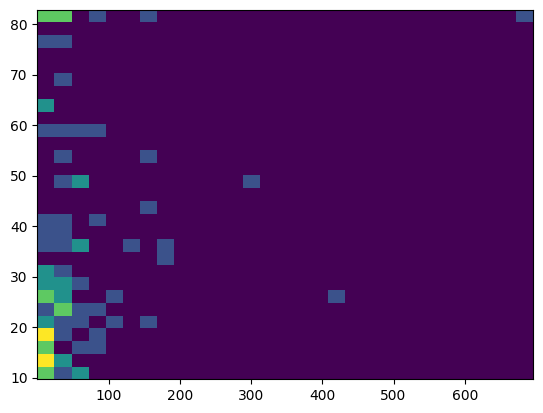

In [17]:
import pandas as pd

# -----------------------------
# Load all snapshots once
# -----------------------------
snap_data = {}

for l in SN:
    snap_data[l] = pd.read_csv(
        f'/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/final_result/snap_{int(l)}_final.csv'
    )


# -----------------------------
# Mutual information function
# -----------------------------
def mutual_two_groups(res, formation_num):

    filtered = res[res['Num'].isin(formation_num)].copy()
    filtered = filtered[pd.notna(filtered['PS'])]

    b1 = filtered['bar_strength'].values
    b2 = filtered['bar_length'].values
    b3 = abs(filtered['PS'].values)

    s1 = filtered['SA'].values
    s2 = filtered['pitch_angle'].values

    total_num = len(b1)

    if total_num < 3:
        return None

    n = int(total_num / 3)

    M_b1_s1 = mutual_info(b1, s1, n, total_num)
    M_b1_s2 = mutual_info(b1, s2, n, total_num)

    M_b2_s1 = mutual_info(b2, s1, n, total_num)
    M_b2_s2 = mutual_info(b2, s2, n, total_num)

    M_b3_s1 = mutual_info(b3, s1, n, total_num)
    M_b3_s2 = mutual_info(b3, s2, n, total_num)

    return M_b1_s1, M_b1_s2, M_b2_s1, M_b2_s2, M_b3_s1, M_b3_s2, total_num


# -----------------------------
# Subsample loop
# -----------------------------
for i in range(100):

    sample = s99['Num'].sample(n=80, replace=False)

    output_file = f'/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_{i}.csv'

    with open(output_file, 'w') as fb0:

        print('snapshot','M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2','total',file=fb0)

        for l in SN:

            try:

                res = snap_data[l]

                result = mutual_two_groups(res, sample)

                if result is None:
                    continue

                M_b1_s1,M_b1_s2,M_b2_s1,M_b2_s2,M_b3_s1,M_b3_s2,total = result

                print(l,
                      M_b1_s1[2],
                      M_b1_s2[2],
                      M_b2_s1[2],
                      M_b2_s2[2],
                      M_b3_s1[2],
                      M_b3_s2[2],
                      total,
                      file=fb0)

            except Exception as e:

                print(l, e)

In [5]:
#Plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Get all csv files
files = glob.glob("/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/*.csv")   # or path/*.csv

df = pd.read_csv(files[0],sep='\s+')
print(df.columns)
selected_cols = ['M_b1_s1','M_b1_s2','M_b2_s1','M_b2_s2','M_b3_s1','M_b3_s2']

means = []

for f in files:
    print(f)
    df = pd.read_csv(f,sep='\s+')
    means.append(df[selected_cols].mean())
    means.append(df.mean())

means_df = pd.DataFrame(means)
print(means_df)

Index(['snapshot', 'M_b1_s1', 'M_b1_s2', 'M_b2_s1', 'M_b2_s2', 'M_b3_s1',
       'M_b3_s2', 'total'],
      dtype='object')
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_95.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_19.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_0.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_57.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_91.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_42.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_54.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_information/sub_sample/mutual_information_subsample_98.csv
/media/anagha/HDD11/Bar_spiral/TNG_50/Mutual_

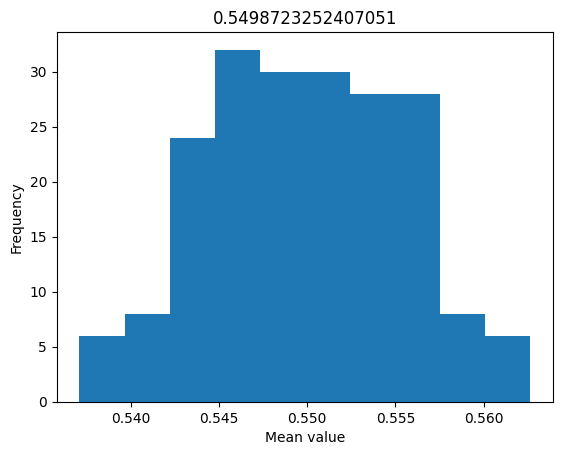

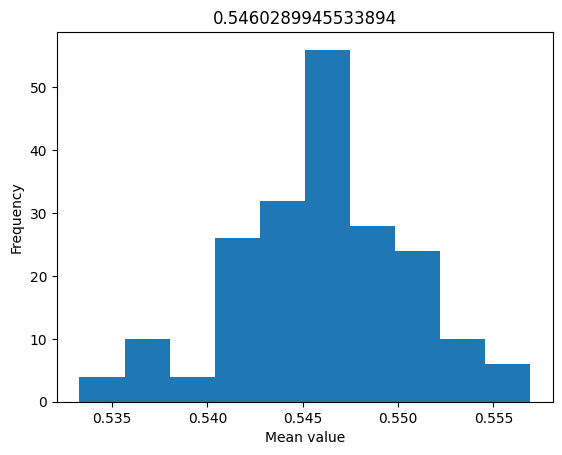

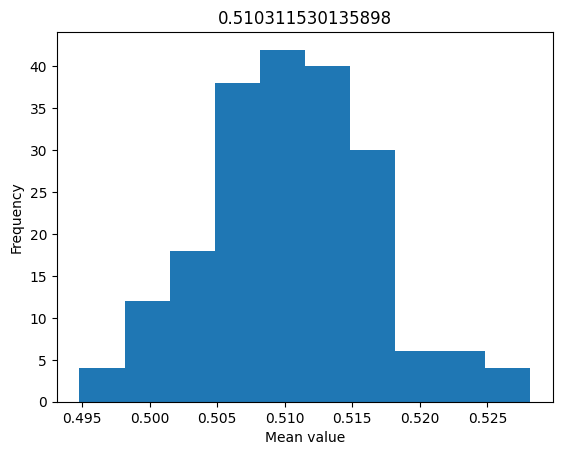

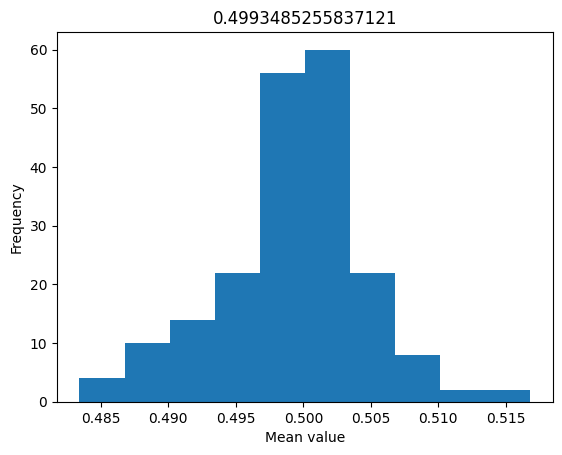

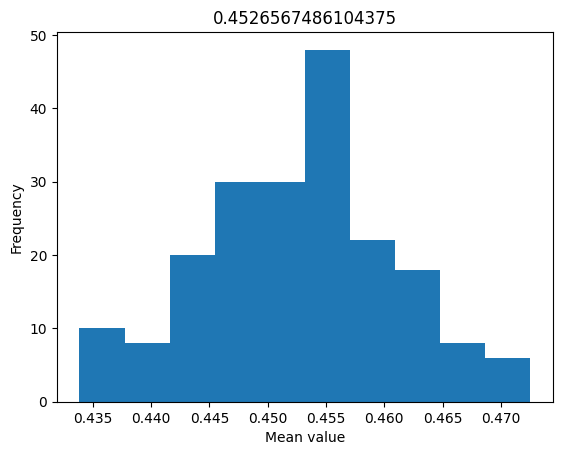

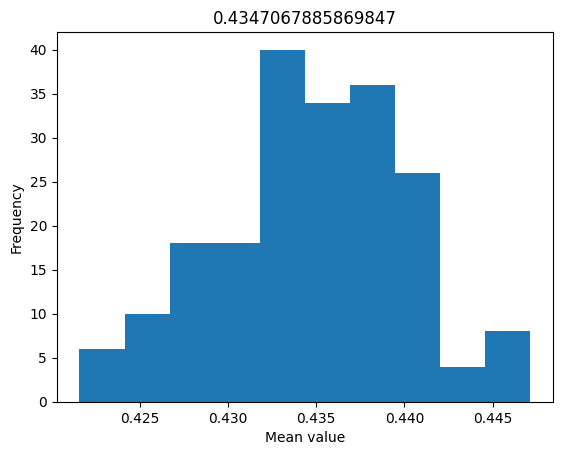

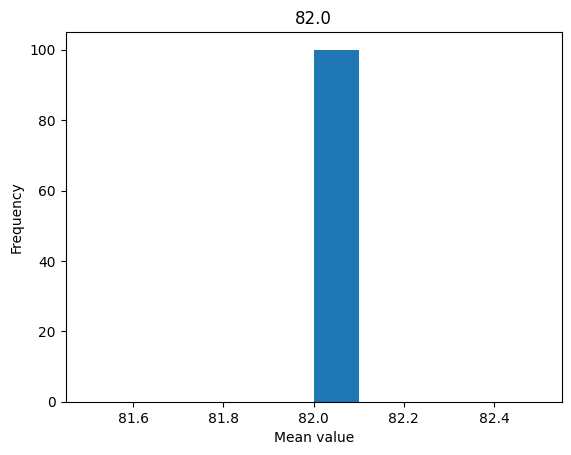

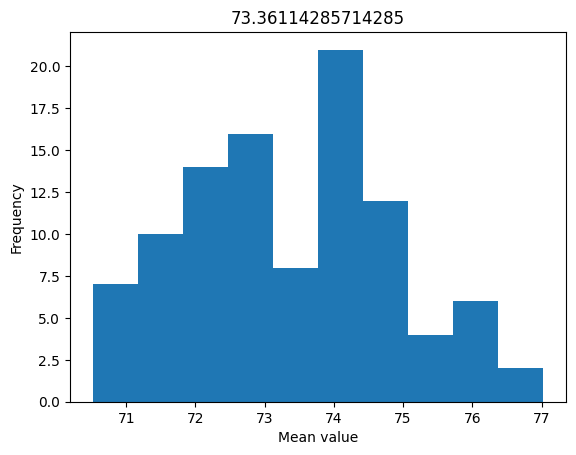

In [7]:
for col in means_df.columns:
    plt.figure()
    plt.hist(means_df[col], bins=10)
    plt.title(np.mean(means_df[col]))           # column name as title
    plt.xlabel("Mean value")
    plt.ylabel("Frequency")
    plt.show()

In [8]:
for col in means_df.columns:
    print(col,'------------------',np.mean(means_df[col]))  

M_b1_s1 ------------------ 0.5498723252407051
M_b1_s2 ------------------ 0.5460289945533894
M_b2_s1 ------------------ 0.510311530135898
M_b2_s2 ------------------ 0.4993485255837121
M_b3_s1 ------------------ 0.4526567486104375
M_b3_s2 ------------------ 0.4347067885869847
snapshot ------------------ 82.0
total ------------------ 73.36114285714285
